<h1> Visualization: If you are infected, are you more worried about yourself or the consequent impact on your family? </h1>
<p> This project uses data from the World COVID-19 Pandemic and Citizen Life Survey, part of a research project that I participated in when I was a graduate research assistant at Seoul National University. The following codes exhibit how I process the data for visualization and visualize it. I have excluded some more detailed processes such as checking the values because I intended to make this presentation look concise. For people who are only interested in the result, please scroll down to the bottom and check the interpretation section. </p>

<h2> Data Pre-processing </h2>

In [1]:
import pandas as pd
import numpy as np
import pyreadstat
import math

import matplotlib.pyplot as plt

In [2]:
path =  #... location of raw data
df, meta = pyreadstat.read_sav(path, usecols=['SQ1', 'qI_4_1', 'qI_4_2'])

In [3]:
df['self_x'] = df['qI_4_1'].apply(lambda x: 6-x)
df['fam_x'] = df['qI_4_2'].apply(lambda x: 6-x)

cities = ['Seoul', 'Daegu', 'Tokyo', 'Osaka', 'Taipei', 'Hong Kong', 'Singapore', 'New York', 'Los Angeles', 'Toronto', 'London', 'Berlin', 'Paris',
                'Vienna', 'Madrid', 'Rome', 'Lisbon', 'Cape Town', 'Stockholm', 'Oslo', 'Moscow', 'Sydney', 'Wellington', 'Manila', 'Sao Paulo',
                'Buenos Aires', 'Santiago', 'Mexico City', 'New Delhi', 'Jakarta']

def city_dic(x):    
    city = cities[int(x)-1]    
    return(city)

df['city'] = df['SQ1'].apply(lambda x: city_dic(x))

In [4]:
x = df.groupby('city')['self_x'].mean().sort_index()
y = df.groupby('city')['fam_x'].mean().sort_index()

data = x.to_frame()
data['fam_x'] = y.values

data.loc[data['fam_x'] > data['self_x'], 'z'] = 'family-oriented'
data.loc[data['fam_x'] <= data['self_x'], 'z'] = 'self-oriented'

<h3> the following cell presents a snippet of the table after pre-processing </h3>

In [5]:
data.head()

,self_x,fam_x,z
city,,,
Berlin,2.904382,2.657371,self-oriented
Buenos Aires,2.312253,1.820158,self-oriented
Cape Town,3.835271,4.098837,family-oriented
Daegu,3.830952,4.409524,family-oriented
Hong Kong,3.695906,4.179337,family-oriented


<h2> Visualization </h2>

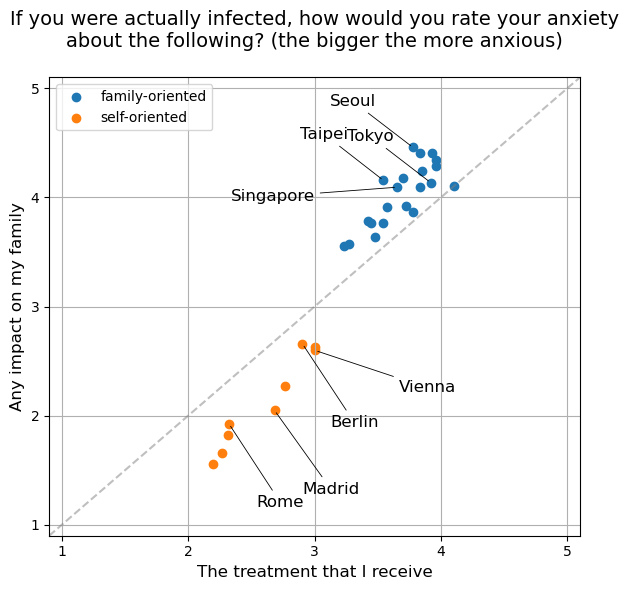

In [6]:
x = data['self_x'].to_list()
y = data['fam_x'].to_list()

line_x = (0, 6)
line_y = (0, 6)

seoul_pos = (data.iloc[21, 0], data.iloc[21, 1])        
tokyo_pos = (data.iloc[26, 0], data.iloc[26, 1])
sing_pos = (data.iloc[22, 0], data.iloc[22, 1])
tpe_pos = (data.iloc[25, 0], data.iloc[25, 1])
        
berl_pos = (data.iloc[0, 0], data.iloc[0, 1])
rom_pos = (data.iloc[18, 0], data.iloc[18, 1])
mad_pos = (data.iloc[9, 0], data.iloc[9, 1])
vie_pos = (data.iloc[28, 0], data.iloc[28, 1])


fig, ax = plt.subplots(figsize=(6, 6))

cate = data.groupby('z')
                   
for n, g in cate:
    ax.scatter(g['self_x'], g['fam_x'], label=n)

ax.plot(line_x, line_y, color='grey', linestyle='--', alpha=0.5)

ax.set_xlabel('The treatment that I receive', fontsize=12)
ax.set_xlim([0.9, 5.1])
ax.set_xticks([1, 2, 3, 4, 5])

ax.set_ylabel('Any impact on my family', fontsize=12)
ax.set_ylim([0.9, 5.1])
ax.set_yticks([1, 2, 3, 4, 5])

###############################################################################################################
#                                                                                                             #
#    The following codes mark the city name of some points to facilitate the interpretation of the figure,    #
#    as this project only does non-interactive figure.                                                        #
#                                                                                                             #
###############################################################################################################
        
for n, m in zip(['Seoul', 'Tokyo', 'Taipei'], [seoul_pos, tokyo_pos, tpe_pos]):
    ax.annotate(n, m, xytext=(-60, 30),
                    textcoords='offset points', zorder=8, arrowprops=dict(arrowstyle='-', lw=0.6), fontsize=12)
    
for n, m in zip(['Singapore'], [sing_pos]):
    ax.annotate(n, m, xytext=(-120, -10),
                    textcoords='offset points', zorder=8, arrowprops=dict(arrowstyle='-', lw=0.6), fontsize=12)
    
for n, m in zip(['Berlin', 'Rome', 'Madrid'], [berl_pos, rom_pos, mad_pos]):
    ax.annotate(n, m, xytext=(20, -60),
                    textcoords='offset points', zorder=8, arrowprops=dict(arrowstyle='-', lw=0.6), fontsize=12)
    
for n, m in zip(['Vienna'], [vie_pos]):
    ax.annotate(n, m, xytext=(60, -30),
                    textcoords='offset points', zorder=8, arrowprops=dict(arrowstyle='-', lw=0.6), fontsize=12)

###############################################################################################################

ax.grid()
ax.legend()

ax.set_title('If you were actually infected, how would you rate your anxiety\nabout the following? (the bigger the more anxious)\n',
            fontsize=14)
fig.tight_layout()
#plt.savefig('portfo3.png', dpi=300)
plt.show()

<h2> Interpretation </h2>

<p> 1. This figure plots the sample means of each city for two related survey items. The X tick represents the degree of anxiety one would feel about the treatment one receive if one were infected, and the Y tick represents the degree of anxiety one would feel about the impact on one's family if one were infected. In other words, the X tick indicates self-oriented anxiety about the pandemic, while the Y tick indicates family-oriented anxiety about the pandemic. </p>
<p> 2. The dotted line represents the location where the degree of self-oriented anxiety and the degree of family-oriented anxiety is the same. Therefore, city points below the dotted line imply the city on average would feel more anxious about themselves than about their families if they were infected, and vice versa. </p>
<p> 3. The result presents two identifiable clusters. One cluster,  marked in blue, represents family-oriented anxiety, with notable examples of Asian cities such as Seoul, Taipei, and Singapore where traditional familial values function. The other cluster, marked in orange, represents self-oriented anxiety, with notable examples such as Rome, Madrid, Berlin, and Vienna. </p>